In [ ]:
import torch
import torch.nn as nn
import pandas as pd
import time
import seaborn as sns
import numpy as np


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [ ]:
# configuration
batch_size = 32
num_epochs = 300
train_losses = []
val_losses = []

seed = 43
np.random.seed(seed)
torch.manual_seed(seed)

In [ ]:
# loading data
data = pd.read_csv("/content/CNT_Chiral_Index.csv")

df_0 = data[data["Metal (1) or Semi (0)"] == 0]
df_1 = data[data["Metal (1) or Semi (0)"] == 1]

# undersample class 1 to match class 0 size
df_0_under = df_0.sample(len(df_1), random_state=seed)

# balanced dataset
data = pd.concat([df_1, df_0_under]).sample(frac=1, random_state=seed)

# selecting features and target
features = ['n', 'm', 'diameter (A)', 'chiral angle (deg.)']
target = 'peakposition from Fermi level (eV)'

X = data[features].values
y = data[target].values.reshape(-1, 1)

In [ ]:
# train, test and split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed)

# scaling features
scaler = StandardScaler().fit(X_train)
x_train_scaled = scaler.transform(X_train)
x_test_scaled = scaler.transform(X_test)

In [ ]:
# converting to tensors
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

x_train_tensor = torch.tensor(x_train_scaled, dtype=torch.float32)
x_test_tensor = torch.tensor(x_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)


In [ ]:
print("train tensor shape:", x_train_tensor.shape)
print("test tensor shape:", x_test_tensor.shape)


train tensor shape: torch.Size([480, 4])
test tensor shape: torch.Size([120, 4])


In [ ]:
# dataloaders
train_loader = DataLoader(TensorDataset(x_train_tensor, y_train_tensor),
                          batch_size=batch_size, shuffle=True)

test_loader = DataLoader(TensorDataset(x_test_tensor, y_test_tensor),
                         batch_size=batch_size, shuffle=False)

In [ ]:
# defining MLP model
class MLPRegression(nn.Module):
  def __init__(self, input_dim):
    super().__init__()
    self.net = nn.Sequential(
        # layer 1
        nn.Linear(input_dim, 128),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Dropout(0.2),

        # layer 2
        nn.Linear(128, 64),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.Dropout(0.1),

        # layer 3
        nn.Linear(64, 32),
        nn.ReLU(),

        # output layer
        nn.Linear(32, 1)
    )
  def forward(self, x):
    return self.net(x)

model = MLPRegression(input_dim=4).to(device)

In [ ]:
print(model)

MLPRegression(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [ ]:
# loss + optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(),
                             lr=1e-3,
                             weight_decay=1e-4)

In [ ]:
# training loop
# starting training time
print("\nstarting training...")
start_time = time.time()

for epoch in range(num_epochs):
  model.train()
  epoch_losses = []

  for xb, yb in train_loader:
    xb, yb = xb.to(device), yb.to(device)

    optimizer.zero_grad()
    preds = model(xb)
    loss = criterion(preds, yb)
    loss.backward()
    optimizer.step()

    epoch_losses.append(loss.item())

  # computing mean loss for each epoch
  epoch_loss = sum(epoch_losses) / len(epoch_losses)

  # saving for plotting
  train_losses.append(epoch_loss)

  # validation step
  model.eval()
  val_epoch_losses = []
  with torch.no_grad():
    for xb_val, yb_val in test_loader:
      xb_val, yb_val = xb_val.to(device), yb_val.to(device)
      val_preds = model(xb_val)
      val_loss = criterion(val_preds, yb_val)
      val_epoch_losses.append(val_loss.item())

  val_epoch_loss = sum(val_epoch_losses) / len(val_epoch_losses)
  val_losses.append(val_epoch_loss)


  if (epoch + 1) % 10 == 0:
    print(f"epoch {epoch + 1}/{num_epochs}, train mse loss = {epoch_loss: .6f}, val mse loss = {val_epoch_loss: .6f}")


starting training...
epoch 10/300, train mse loss =  0.060519, val mse loss =  0.074701
epoch 20/300, train mse loss =  0.064660, val mse loss =  0.074585
epoch 30/300, train mse loss =  0.053390, val mse loss =  0.070437
epoch 40/300, train mse loss =  0.048489, val mse loss =  0.067175
epoch 50/300, train mse loss =  0.052887, val mse loss =  0.059749
epoch 60/300, train mse loss =  0.047288, val mse loss =  0.057881
epoch 70/300, train mse loss =  0.055585, val mse loss =  0.065773
epoch 80/300, train mse loss =  0.056897, val mse loss =  0.065095
epoch 90/300, train mse loss =  0.044904, val mse loss =  0.056758
epoch 100/300, train mse loss =  0.039949, val mse loss =  0.060653
epoch 110/300, train mse loss =  0.052466, val mse loss =  0.063830
epoch 120/300, train mse loss =  0.056188, val mse loss =  0.062029
epoch 130/300, train mse loss =  0.054815, val mse loss =  0.059119
epoch 140/300, train mse loss =  0.047894, val mse loss =  0.060087
epoch 150/300, train mse loss =  0.

In [ ]:
# evaluation
# add time
model.eval()

with torch.no_grad():
  y_pred = model(x_test_tensor.to(device)).cpu().numpy()

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("test performance")
print(f"mse: {mse:.6f}")
print(f"mae: {mae:.6f}")
print(f"r2 score: {r2:.6f}")

train_end = time.time()
train_time = train_end - start_time
total_time = train_end - start_time

# time summary
print("\ntime summary")
print(f"training time:        {train_time:.1f} seconds")
print(f"total runtime:         {total_time:.1f} seconds")
print(f"total train + start time: {total_time:.1f} seconds")



test performance
mse: 0.056490
mae: 0.189294
r2 score: 0.693349

time summary
training time:        14.6 seconds
total runtime:         14.6 seconds
total train + start time: 14.6 seconds


In [ ]:
print(train_losses[:5])

[0.09533078794678053, 0.08143281700710456, 0.08072724714875221, 0.0663759016742309, 0.07499032964309056]


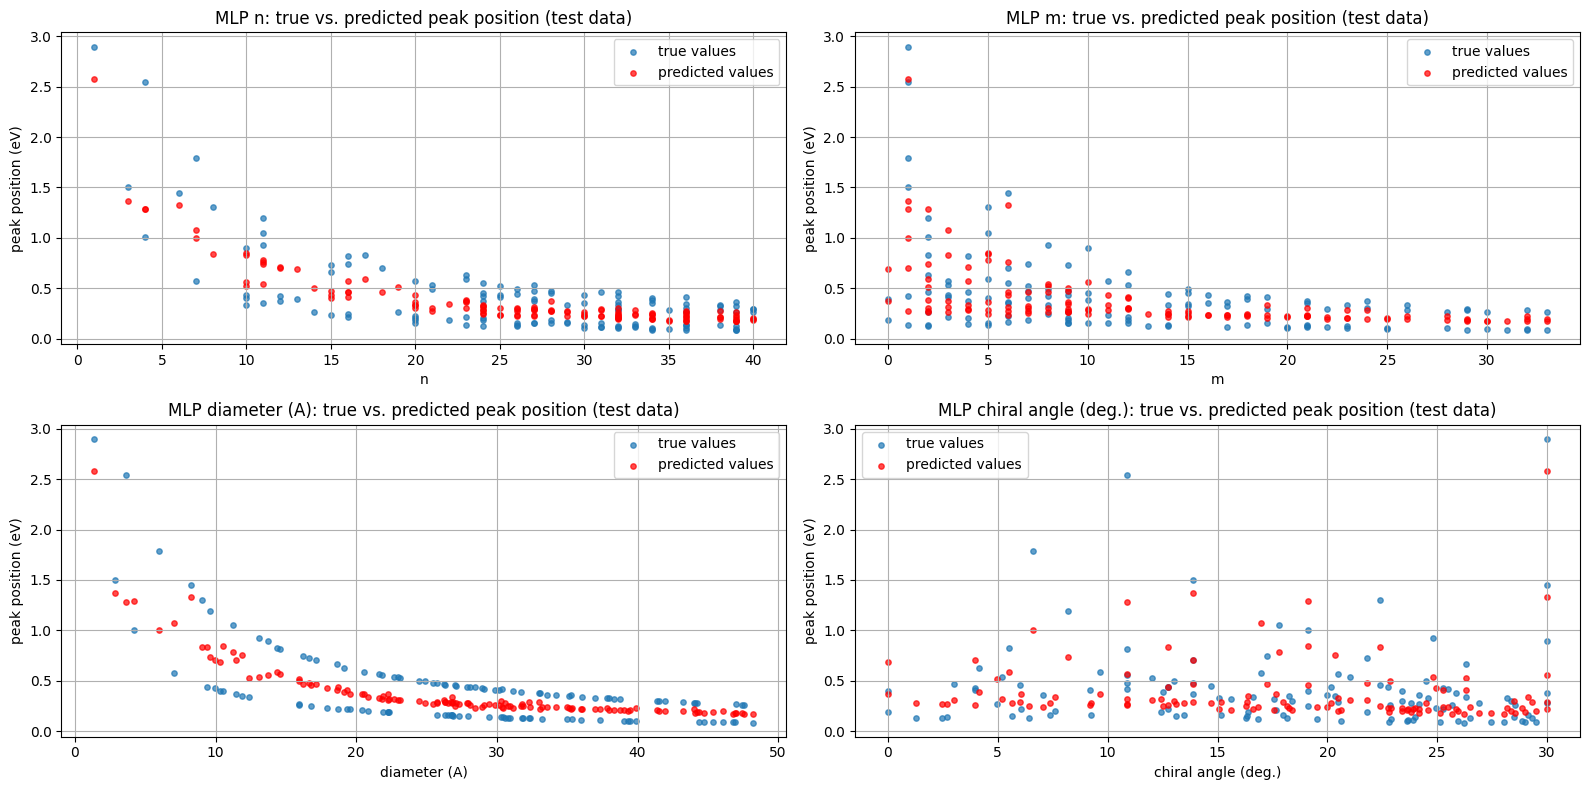

In [ ]:
num_features = len(features)
plt.figure(figsize=(16, 4 * ((num_features + 1) // 2))) # adjust figure height dynamically

for i, feature_name in enumerate(features):
    plt.subplot((num_features + 1) // 2, 2, i + 1) # create 2 columns for subplots
    plt.scatter(X_test[:, i], y_test, s=15, alpha=0.7, label='true values')
    plt.scatter(X_test[:, i], y_pred, s=15, alpha=0.7, color='red', label='predicted values')
    plt.xlabel(feature_name)
    plt.ylabel('peak position (eV)')
    plt.title(f'MLP {feature_name}: true vs. predicted peak position (test data)')
    plt.grid(True)
    plt.legend()

plt.savefig('features_scatter_plot')
plt.tight_layout()
plt.show()

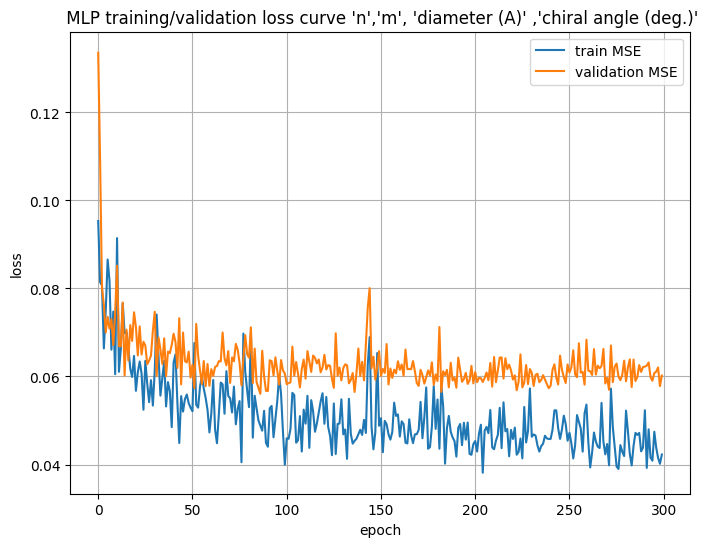

In [ ]:
# plotting training loss curve
plt.figure(figsize=(8, 6))

plt.plot(train_losses, label="train MSE")
plt.plot(val_losses, label="validation MSE")


plt.xlabel("epoch")
plt.ylabel("loss")
plt.title(" MLP training/validation loss curve 'n','m', 'diameter (A)' ,'chiral angle (deg.)'")
plt.grid(True)
plt.legend()
plt.savefig('validation_training_loss_curve_option1')
plt.show()

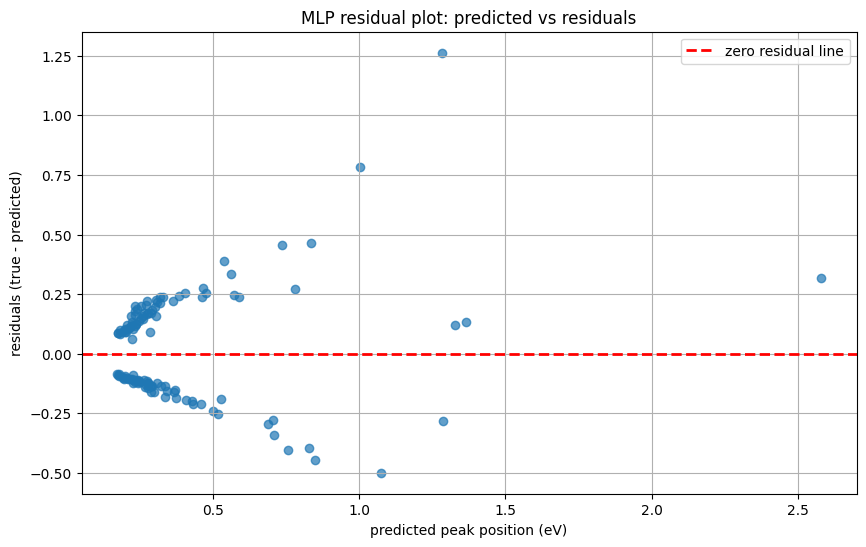

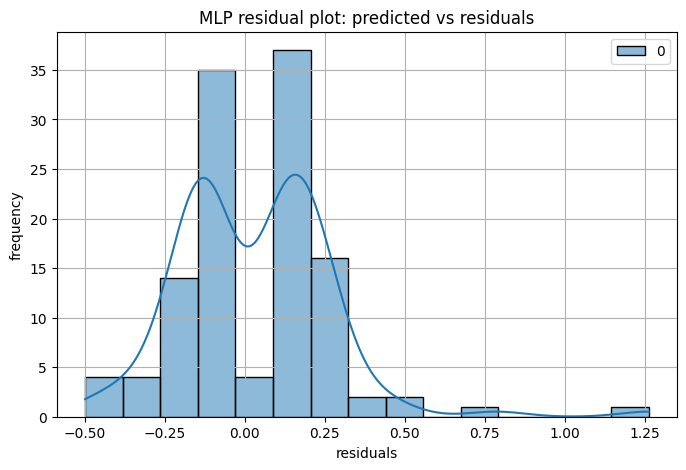

In [ ]:
# calculate residuals
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='zero residual line')
plt.xlabel('predicted peak position (eV)')
plt.ylabel('residuals (true - predicted)')
plt.title('MLP residual plot: predicted vs residuals')
plt.grid(True)
plt.savefig("MLP 'n' and 'm' residual plot")
plt.legend()
plt.show()

# helpful to see the distribution of residuals
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True)
plt.title('MLP residual plot: predicted vs residuals')
plt.xlabel('residuals')
plt.ylabel('frequency')
plt.savefig('MLP distribution of residuals')
plt.grid(True)
plt.show()